# Tarefa 02 — Suavização, Remoção de Ruído e Detecção de Bordas

## 1. Introdução

Nesta atividade, será utilizado o mini dataset construído na atividade anterior, composto por duas classes: **Skate** e **Sapato**.

O objetivo é aplicar técnicas de filtragem espacial para suavização, remoção de ruído e detecção de bordas em imagens reais. Como as imagens foram capturadas em condições comuns do dia a dia, elas apresentam degradações como baixa iluminação, sombras, pequenas variações de intensidade, perda de nitidez e possíveis ruídos do sensor.

A análise seguirá a estrutura:

**problema → código → visualização → interpretação**

Assim, cada etapa terá não apenas o código, mas também a visualização dos resultados e uma interpretação técnica.

In [ ]:
# Instalação/validação do OpenCV no ambiente do notebook

try:
    import cv2
    print("OpenCV já está instalado.")
    print("Versão:", cv2.__version__)
except ModuleNotFoundError:
    import sys
    print("OpenCV não encontrado. Instalando opencv-python...")
    !{sys.executable} -m pip install opencv-python

    import cv2
    print("OpenCV instalado com sucesso.")
    print("Versão:", cv2.__version__)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
try:
    from google.colab import files
    ambiente_colab = True
except ImportError:
    ambiente_colab = False
    print("Rodando localmente. As imagens serão lidas da pasta imagens/.")
import glob
import os

ModuleNotFoundError: No module named 'cv2'

## 2. Upload das imagens

Nesta etapa, serão enviadas ao notebook as imagens selecionadas do dataset anterior.

Foram escolhidas 4 imagens:

- `skate_01`
- `skate_05`
- `sapato_02`
- `sapato_03`

Essas imagens foram escolhidas por apresentarem características úteis para análise de suavização, ruído e detecção de bordas.

In [ ]:
# Verificação das imagens locais
arquivos_imagens = glob.glob("imagens/*")

if len(arquivos_imagens) > 0:
    print("Imagens encontradas na pasta imagens/. Upload manual não é necessário.")
    for arquivo in arquivos_imagens:
        print(arquivo)
else:
    print("Nenhuma imagem encontrada na pasta imagens/.")
    print("Se estiver no Google Colab, envie as imagens manualmente ou carregue a pasta imagens junto com o notebook.")

In [ ]:
def localizar_arquivo(prefixo):
    """
    Localiza a imagem pelo início do nome.
    Funciona tanto com imagens na raiz quanto dentro da pasta imagens/.
    """
    arquivos = glob.glob(f"{prefixo}*")

    if len(arquivos) == 0:
        arquivos = glob.glob(f"imagens/{prefixo}*")

    if len(arquivos) == 0:
        raise FileNotFoundError(f"Nenhum arquivo encontrado começando com: {prefixo}")

    return arquivos[0]

# Imagens selecionadas para a atividade
imagens_info = [
    {
        "arquivo": localizar_arquivo("skate_01"),
        "nome": "skate_01",
        "classe": "Skate",
        "degradacao": "Pequenas variações de intensidade, textura irregular, sujeira e riscos na superfície do shape",
        "hipotese": "A degradação pode estar relacionada ao desgaste natural do objeto, sujeira acumulada, reflexão do piso e compressão da imagem"
    },
    {
        "arquivo": localizar_arquivo("skate_05"),
        "nome": "skate_05",
        "classe": "Skate",
        "degradacao": "Baixa iluminação, baixa nitidez, pouca definição de detalhes e possível ruído em regiões escuras",
        "hipotese": "A degradação provavelmente foi causada por pouca luz no ambiente e limitação do sensor da câmera ao capturar áreas escuras"
    },
    {
        "arquivo": localizar_arquivo("sapato_02"),
        "nome": "sapato_02",
        "classe": "Sapato",
        "degradacao": "Sombra, variação de iluminação e textura fina do tecido",
        "hipotese": "A degradação pode ter sido causada pela iluminação lateral do ambiente, sombras do próprio objeto e detalhes finos do material do sapato"
    },
    {
        "arquivo": localizar_arquivo("sapato_03"),
        "nome": "sapato_03",
        "classe": "Sapato",
        "degradacao": "Baixa iluminação, contraluz, perda de detalhes e pequenas variações aleatórias de intensidade",
        "hipotese": "A degradação provavelmente ocorreu por captura contra a fonte de luz, gerando regiões muito escuras e ruído do sensor"
    }
]

# Conferir arquivos encontrados
for item in imagens_info:
    print(f"{item['nome']} -> {item['arquivo']}")

## 3. Seleção das imagens

Foram selecionadas duas imagens da classe **Skate** e duas imagens da classe **Sapato**, conforme solicitado na atividade.

O critério de escolha foi selecionar imagens com degradações reais, como baixa iluminação, sombras, perda de nitidez, pequenas variações de intensidade e textura irregular.

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax = ax.flatten()

for i, item in enumerate(imagens_info):
    img_bgr = cv2.imread(item["arquivo"])

    if img_bgr is None:
        raise ValueError(f"Erro ao carregar a imagem: {item['arquivo']}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    ax[i].imshow(img_rgb)
    ax[i].set_title(f"{item['nome']} — Classe: {item['classe']}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
tabela_degradacoes = pd.DataFrame([
    {
        "Imagem": item["nome"],
        "Classe": item["classe"],
        "Degradação observada": item["degradacao"],
        "Hipótese sobre a origem": item["hipotese"]
    }
    for item in imagens_info
])

tabela_degradacoes

### Interpretação técnica da seleção das imagens

As imagens escolhidas representam situações comuns em visão computacional aplicada a imagens reais. Diferentemente de imagens controladas em laboratório, essas capturas apresentam variações de iluminação, sombras, texturas irregulares, regiões escuras e perda de nitidez.

Na classe **Skate**, a imagem `skate_01` possui boa visibilidade geral, mas apresenta sujeira, riscos e textura irregular na superfície do shape. Já a imagem `skate_05` apresenta baixa iluminação e menor definição visual, o que pode dificultar a detecção correta das bordas.

Na classe **Sapato**, a imagem `sapato_02` possui textura fina no tecido e sombras causadas pela iluminação do ambiente. A imagem `sapato_03` apresenta contraluz e regiões muito escuras, o que pode gerar ruído e perda de detalhes importantes.

Essas degradações podem prejudicar etapas posteriores, como segmentação e classificação, pois pequenas variações de intensidade podem ser interpretadas incorretamente como bordas ou padrões relevantes. Por isso, nas próximas etapas serão aplicados filtros de suavização e operadores de detecção de bordas para comparar os resultados.

## 4. Aplicação dos filtros de suavização

Nesta etapa, serão aplicados filtros espaciais de suavização nas quatro imagens selecionadas do dataset.

O objetivo é reduzir pequenas variações de intensidade, ruídos e granulações sem destruir completamente as bordas importantes dos objetos. Essa etapa é importante porque imagens reais podem apresentar ruídos que prejudicam tarefas posteriores, como segmentação, classificação e detecção de bordas.

Serão aplicados os seguintes filtros:

- Filtro da Média com kernel 3x3;
- Filtro da Média com kernel 5x5;
- Filtro Gaussiano com sigma = 1;
- Filtro Gaussiano com sigma = 3;
- Filtro da Mediana com kernel 3x3;
- Filtro da Mediana com kernel 5x5.

Após a aplicação dos filtros, serão calculadas a média e a variância dos níveis de cinza. A variância será usada como uma medida estatística para observar o quanto a suavização tornou a imagem mais homogênea.

In [ ]:
def carregar_imagem(caminho):
    """
    Carrega a imagem em RGB e em escala de cinza.
    RGB será usado para visualização.
    Escala de cinza será usada para aplicar filtros e calcular métricas.
    """
    img_bgr = cv2.imread(caminho)

    if img_bgr is None:
        raise ValueError(f"Erro ao carregar a imagem: {caminho}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    return img_rgb, img_gray


def aplicar_filtros_suavizacao(img_gray):
    """
    Aplica os filtros de suavização pedidos na atividade.
    """
    filtros = {
        "Original": img_gray,
        "Média 3x3": cv2.blur(img_gray, (3, 3)),
        "Média 5x5": cv2.blur(img_gray, (5, 5)),
        "Gaussiano σ=1": cv2.GaussianBlur(img_gray, (5, 5), 1),
        "Gaussiano σ=3": cv2.GaussianBlur(img_gray, (5, 5), 3),
        "Mediana 3x3": cv2.medianBlur(img_gray, 3),
        "Mediana 5x5": cv2.medianBlur(img_gray, 5)
    }

    return filtros


def calcular_media_variancia(img_gray):
    """
    Calcula a média e a variância dos níveis de cinza.
    """
    media = np.mean(img_gray)
    variancia = np.var(img_gray)

    return media, variancia

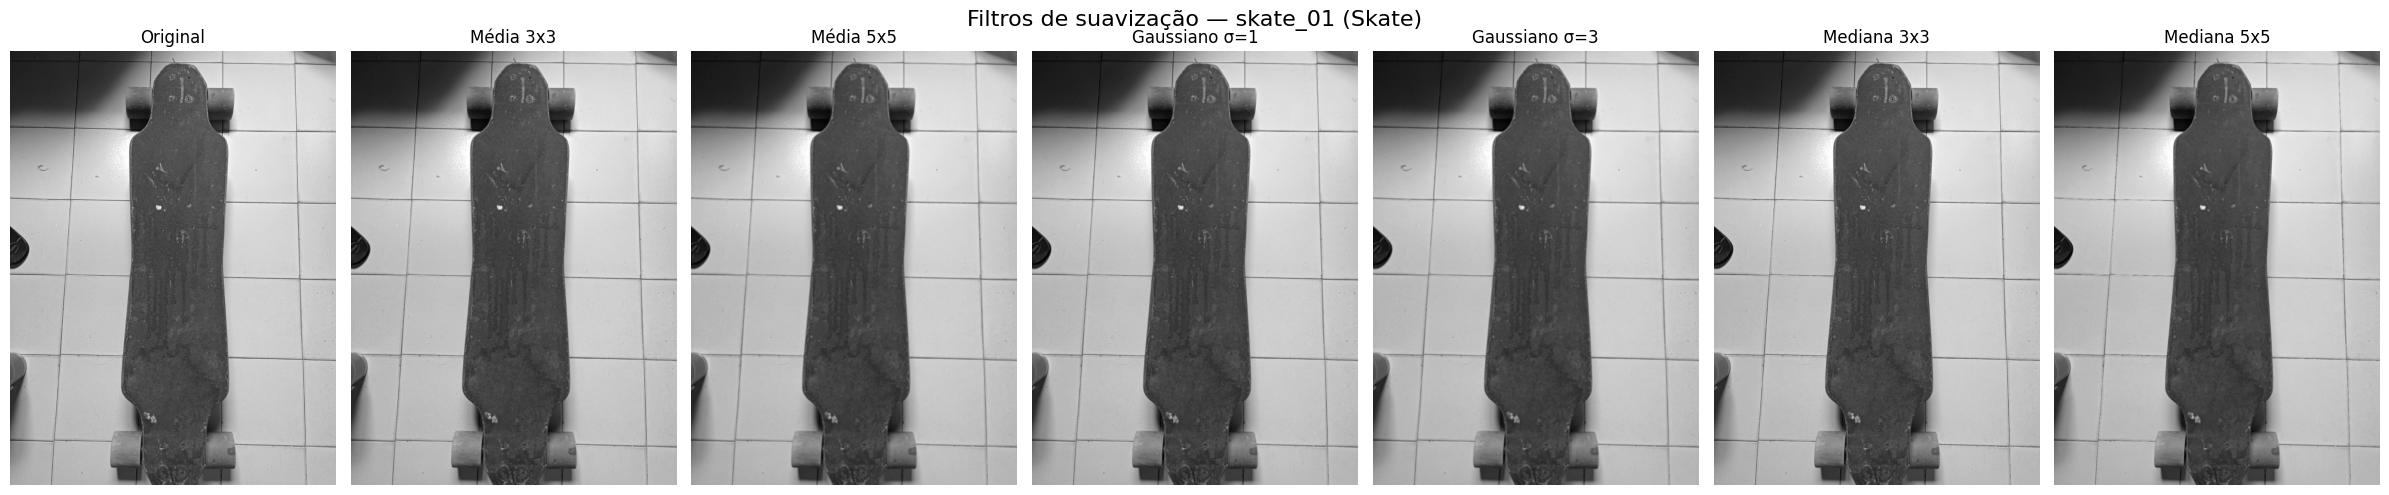

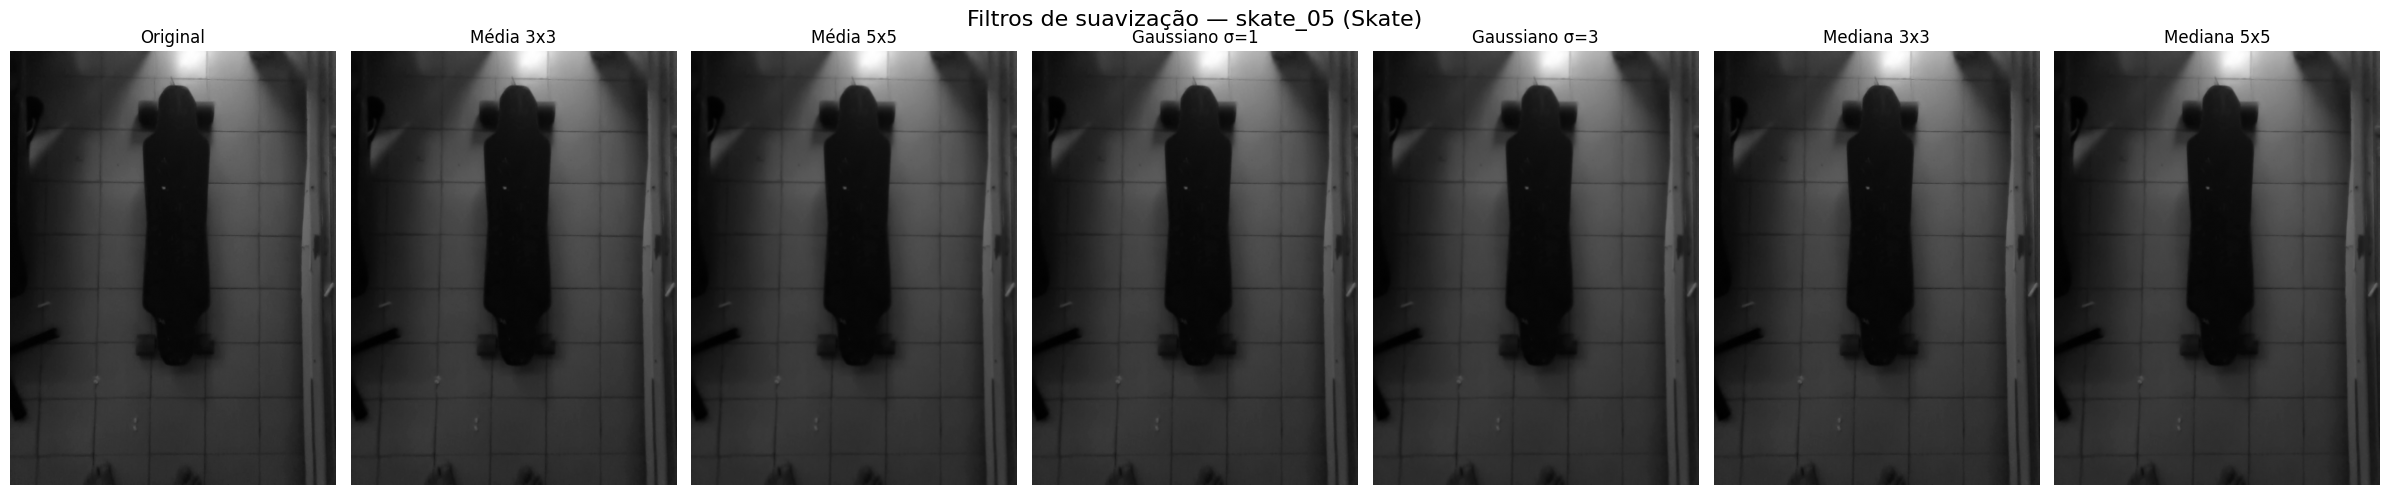

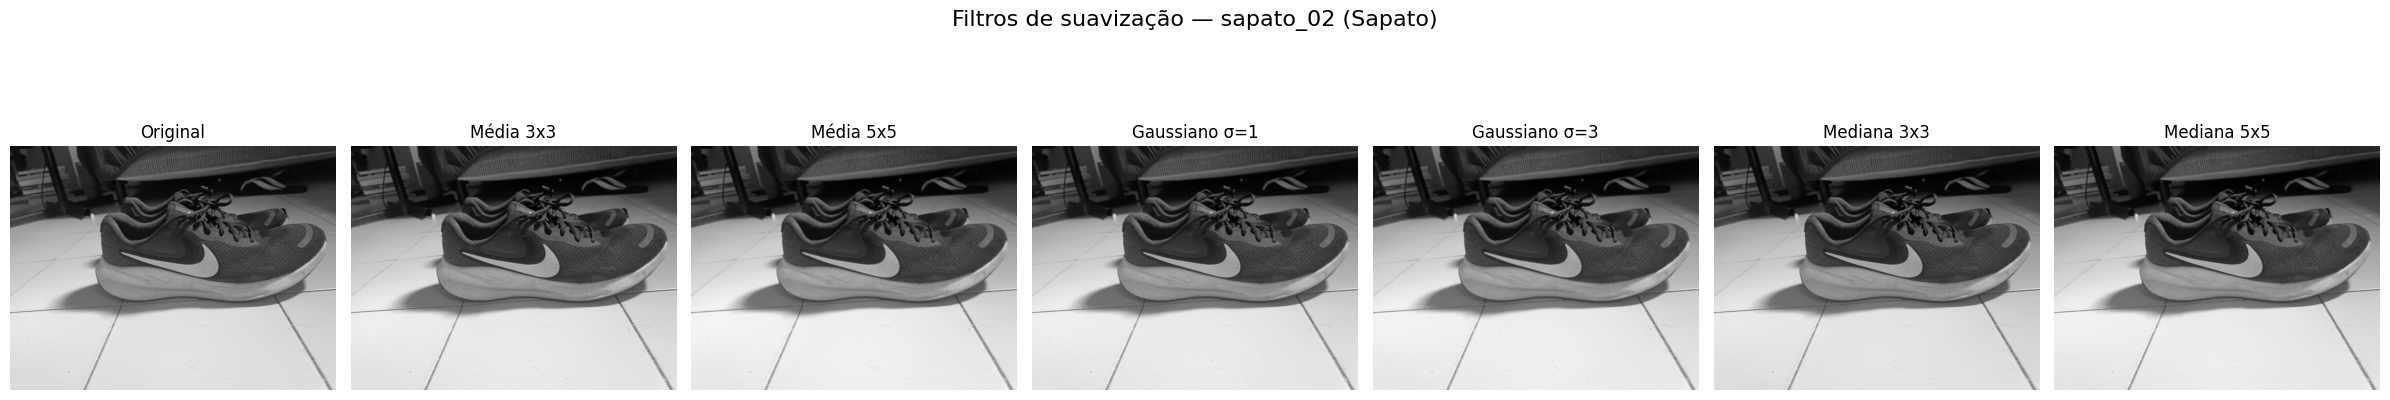

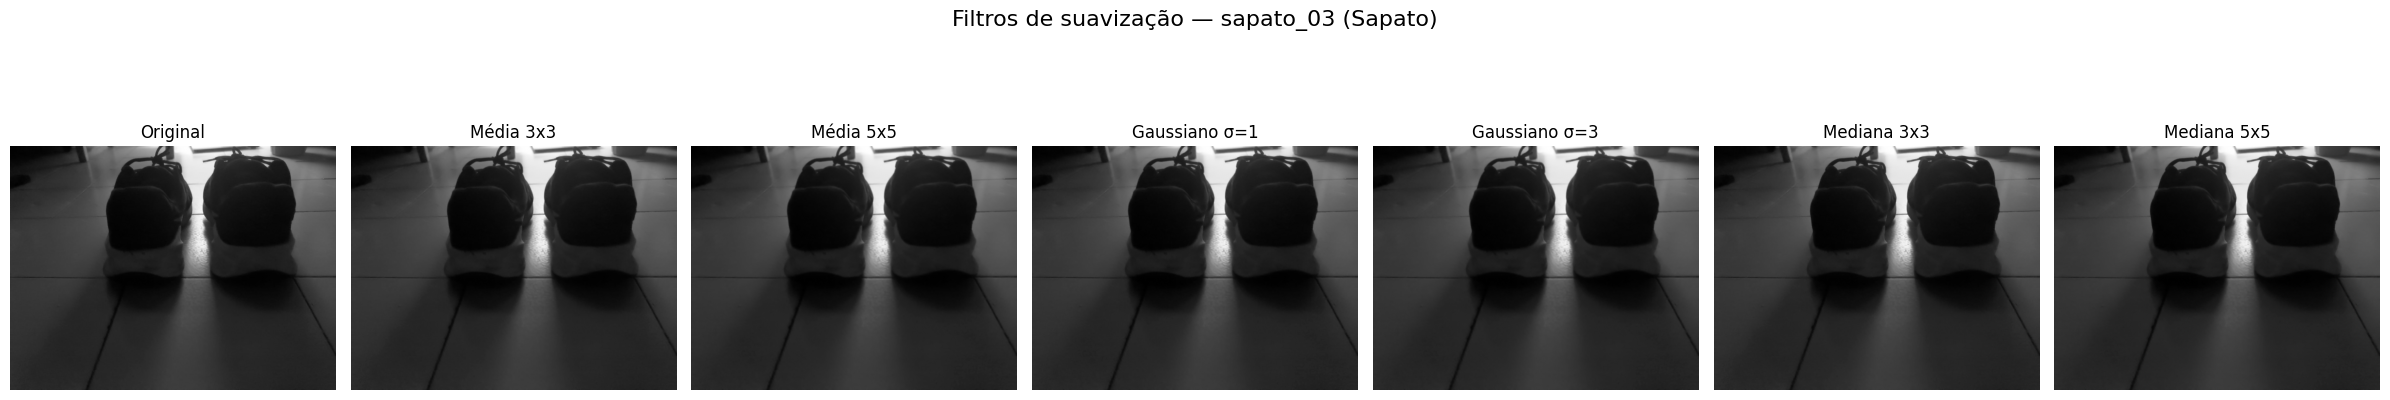

In [ ]:
resultados_suavizacao = {}

for item in imagens_info:
    nome = item["nome"]
    caminho = item["arquivo"]

    img_rgb, img_gray = carregar_imagem(caminho)
    filtros = aplicar_filtros_suavizacao(img_gray)

    resultados_suavizacao[nome] = {
        "classe": item["classe"],
        "rgb": img_rgb,
        "gray": img_gray,
        "filtros": filtros
    }

    fig, ax = plt.subplots(1, 7, figsize=(24, 5))

    titulos = [
        "Original",
        "Média 3x3",
        "Média 5x5",
        "Gaussiano σ=1",
        "Gaussiano σ=3",
        "Mediana 3x3",
        "Mediana 5x5"
    ]

    for i, titulo in enumerate(titulos):
        ax[i].imshow(filtros[titulo], cmap="gray")
        ax[i].set_title(titulo)
        ax[i].axis("off")

    plt.suptitle(f"Filtros de suavização — {nome} ({item['classe']})", fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
dados_metricas_suavizacao = []

for item in imagens_info:
    nome = item["nome"]
    classe = item["classe"]

    filtros = resultados_suavizacao[nome]["filtros"]

    for tecnica, imagem_filtrada in filtros.items():
        media, variancia = calcular_media_variancia(imagem_filtrada)

        dados_metricas_suavizacao.append({
            "Imagem": nome,
            "Classe": classe,
            "Técnica": tecnica,
            "Média dos níveis de cinza": round(media, 2),
            "Variância dos níveis de cinza": round(variancia, 2)
        })

tabela_suavizacao = pd.DataFrame(dados_metricas_suavizacao)

tabela_suavizacao

,Imagem,Classe,Técnica,Média dos níveis de cinza,Variância dos níveis de cinza
0,skate_01,Skate,Original,152.75,3897.55
1,skate_01,Skate,Média 3x3,152.75,3840.66
2,skate_01,Skate,Média 5x5,152.75,3802.36
3,skate_01,Skate,Gaussiano σ=1,152.75,3832.24
4,skate_01,Skate,Gaussiano σ=3,152.75,3805.07
5,skate_01,Skate,Mediana 3x3,152.77,3875.87
6,skate_01,Skate,Mediana 5x5,152.94,3858.47
7,skate_05,Skate,Original,48.54,837.33
8,skate_05,Skate,Média 3x3,48.54,836.35
9,skate_05,Skate,Média 5x5,48.54,834.78


In [ ]:
tabela_comparativa_variancia = tabela_suavizacao.copy()

variancias_originais = tabela_comparativa_variancia[
    tabela_comparativa_variancia["Técnica"] == "Original"
][["Imagem", "Variância dos níveis de cinza"]]

variancias_originais = variancias_originais.rename(
    columns={"Variância dos níveis de cinza": "Variância original"}
)

tabela_comparativa_variancia = tabela_comparativa_variancia.merge(
    variancias_originais,
    on="Imagem"
)

tabela_comparativa_variancia["Redução da variância"] = (
    tabela_comparativa_variancia["Variância original"] -
    tabela_comparativa_variancia["Variância dos níveis de cinza"]
)

tabela_comparativa_variancia["Redução percentual da variância (%)"] = (
    tabela_comparativa_variancia["Redução da variância"] /
    tabela_comparativa_variancia["Variância original"] * 100
).round(2)

tabela_comparativa_variancia

,Imagem,Classe,Técnica,Média dos níveis de cinza,Variância dos níveis de cinza,Variância original,Redução da variância,Redução percentual da variância (%)
0,skate_01,Skate,Original,152.75,3897.55,3897.55,0.00,0.00
1,skate_01,Skate,Média 3x3,152.75,3840.66,3897.55,56.89,1.46
2,skate_01,Skate,Média 5x5,152.75,3802.36,3897.55,95.19,2.44
3,skate_01,Skate,Gaussiano σ=1,152.75,3832.24,3897.55,65.31,1.68
4,skate_01,Skate,Gaussiano σ=3,152.75,3805.07,3897.55,92.48,2.37
5,skate_01,Skate,Mediana 3x3,152.77,3875.87,3897.55,21.68,0.56
6,skate_01,Skate,Mediana 5x5,152.94,3858.47,3897.55,39.08,1.00
7,skate_05,Skate,Original,48.54,837.33,837.33,0.00,0.00
8,skate_05,Skate,Média 3x3,48.54,836.35,837.33,0.98,0.12
9,skate_05,Skate,Média 5x5,48.54,834.78,837.33,2.55,0.30


### Interpretação técnica dos filtros de suavização

A aplicação dos filtros de suavização mostrou como diferentes técnicas afetam as imagens do dataset Skate/Sapato.

O **filtro da Média** reduziu pequenas variações de intensidade ao substituir cada pixel pela média dos pixels vizinhos. O kernel 5x5 produziu uma suavização mais forte do que o 3x3, pois considera uma vizinhança maior. Porém, esse aumento também pode causar maior borramento e perda de detalhes finos, principalmente nas bordas do skate e do sapato.

O **filtro Gaussiano** realizou uma suavização mais controlada, pois dá maior peso aos pixels próximos ao centro da janela. Com `sigma = 3`, o efeito de suavização foi mais intenso do que com `sigma = 1`. Esse filtro é útil quando se deseja reduzir ruído sem aplicar uma média tão uniforme em toda a vizinhança.

O **filtro da Mediana** apresentou bom comportamento para preservar transições e reduzir pontos isolados de ruído, pois substitui o pixel central pelo valor mediano da vizinhança. Em comparação com a média, ele tende a preservar melhor algumas bordas, especialmente quando há pequenas variações pontuais na imagem.

Pela tabela de métricas, é possível observar a mudança na **média** e na **variância** dos níveis de cinza. A média indica o brilho geral da imagem, enquanto a variância indica o quanto os valores dos pixels estão espalhados. Após a suavização, espera-se uma redução da variância, pois os filtros tornam os pixels vizinhos mais parecidos e a imagem mais homogênea.

No entanto, a redução da variância não significa automaticamente que o resultado é sempre melhor. Uma variância muito menor pode indicar que o ruído foi reduzido, mas também pode indicar perda de textura, detalhes e bordas importantes. Por isso, a escolha do melhor filtro deve considerar tanto a tabela estatística quanto a comparação visual.

Para as próximas etapas, será importante escolher um filtro que reduza ruídos e pequenas variações sem apagar totalmente as bordas principais dos objetos. Essa escolha influencia diretamente a detecção de bordas, pois filtros muito fracos deixam bordas falsas causadas por ruído, enquanto filtros muito fortes podem apagar bordas reais.

## 5. Detecção de bordas sem suavização prévia

Nesta etapa, os operadores de borda serão aplicados diretamente nas imagens originais em escala de cinza. O objetivo é analisar como Sobel, Prewitt e Canny se comportam antes da suavização, observando bordas falsas, sensibilidade ao ruído e continuidade das bordas reais.


In [ ]:
def aplicar_sobel(img_gray):
    """
    Aplica o operador de Sobel nos eixos X e Y e calcula a magnitude do gradiente.
    """
    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude_sobel = cv2.magnitude(sobel_x, sobel_y)

    return {
        "Sobel X": cv2.convertScaleAbs(sobel_x),
        "Sobel Y": cv2.convertScaleAbs(sobel_y),
        "Magnitude Sobel": cv2.convertScaleAbs(magnitude_sobel)
    }


def aplicar_prewitt(img_gray):
    """
    Aplica o operador de Prewitt com kernels manuais e calcula a magnitude do gradiente.
    """
    kernel_x = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32)

    kernel_y = np.array([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1]
    ], dtype=np.float32)

    prewitt_x = cv2.filter2D(img_gray, cv2.CV_64F, kernel_x)
    prewitt_y = cv2.filter2D(img_gray, cv2.CV_64F, kernel_y)
    magnitude_prewitt = cv2.magnitude(prewitt_x, prewitt_y)

    prewitt_x_vis = cv2.normalize(np.abs(prewitt_x), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    prewitt_y_vis = cv2.normalize(np.abs(prewitt_y), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    magnitude_prewitt_vis = cv2.normalize(np.abs(magnitude_prewitt), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return {
        "Prewitt X": prewitt_x_vis,
        "Prewitt Y": prewitt_y_vis,
        "Magnitude Prewitt": magnitude_prewitt_vis
    }


def aplicar_canny(img_gray):
    """
    Aplica o detector de bordas de Canny com dois pares de limiares.
    """
    return {
        "Canny 50-100": cv2.Canny(img_gray, 50, 100),
        "Canny 100-200": cv2.Canny(img_gray, 100, 200)
    }


def contar_bordas(img_borda, limiar=50):
    """
    Conta pixels de borda. Em imagens binárias do Canny, conta pixels maiores que zero.
    Em mapas de Sobel e Prewitt, conta pixels acima do limiar informado.
    """
    valores_unicos = np.unique(img_borda)

    if np.all(np.isin(valores_unicos, [0, 255])):
        return int(np.count_nonzero(img_borda > 0))

    return int(np.count_nonzero(img_borda > limiar))


In [ ]:
resultados_bordas_sem_suavizacao = {}

for item in imagens_info:
    nome = item["nome"]
    caminho = item["arquivo"]

    _, img_gray = carregar_imagem(caminho)
    sobel = aplicar_sobel(img_gray)
    prewitt = aplicar_prewitt(img_gray)
    canny = aplicar_canny(img_gray)

    resultados_bordas_sem_suavizacao[nome] = {
        "classe": item["classe"],
        "gray": img_gray,
        "sobel": sobel,
        "prewitt": prewitt,
        "canny": canny
    }

    imagens_visualizacao = [
        ("Original em cinza", img_gray),
        ("Sobel X", sobel["Sobel X"]),
        ("Sobel Y", sobel["Sobel Y"]),
        ("Magnitude Sobel", sobel["Magnitude Sobel"]),
        ("Prewitt X", prewitt["Prewitt X"]),
        ("Prewitt Y", prewitt["Prewitt Y"]),
        ("Magnitude Prewitt", prewitt["Magnitude Prewitt"]),
        ("Canny 50-100", canny["Canny 50-100"]),
        ("Canny 100-200", canny["Canny 100-200"])
    ]

    fig, ax = plt.subplots(1, 9, figsize=(30, 5))

    for i, (titulo, imagem) in enumerate(imagens_visualizacao):
        ax[i].imshow(imagem, cmap="gray")
        ax[i].set_title(titulo)
        ax[i].axis("off")

    plt.suptitle(f"Detecção de bordas sem suavização prévia — {nome} ({item['classe']})", fontsize=16)
    plt.tight_layout()
    plt.show()


In [ ]:
dados_bordas_sem_suavizacao = []

for item in imagens_info:
    nome = item["nome"]
    classe = item["classe"]
    resultados = resultados_bordas_sem_suavizacao[nome]

    dados_bordas_sem_suavizacao.extend([
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Sobel",
            "Configuração": "Sobel X",
            "Contagem de pixels de borda": contar_bordas(resultados["sobel"]["Sobel X"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Sobel",
            "Configuração": "Sobel Y",
            "Contagem de pixels de borda": contar_bordas(resultados["sobel"]["Sobel Y"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Sobel",
            "Configuração": "Magnitude Sobel",
            "Contagem de pixels de borda": contar_bordas(resultados["sobel"]["Magnitude Sobel"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Prewitt",
            "Configuração": "Prewitt X",
            "Contagem de pixels de borda": contar_bordas(resultados["prewitt"]["Prewitt X"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Prewitt",
            "Configuração": "Prewitt Y",
            "Contagem de pixels de borda": contar_bordas(resultados["prewitt"]["Prewitt Y"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Prewitt",
            "Configuração": "Magnitude Prewitt",
            "Contagem de pixels de borda": contar_bordas(resultados["prewitt"]["Magnitude Prewitt"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Canny",
            "Configuração": "Canny 50-100",
            "Contagem de pixels de borda": contar_bordas(resultados["canny"]["Canny 50-100"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Canny",
            "Configuração": "Canny 100-200",
            "Contagem de pixels de borda": contar_bordas(resultados["canny"]["Canny 100-200"])
        }
    ])

tabela_bordas_sem_suavizacao = pd.DataFrame(dados_bordas_sem_suavizacao)

tabela_bordas_sem_suavizacao


### Interpretação técnica da detecção de bordas sem suavização prévia

Nesta etapa, os operadores foram aplicados diretamente nas imagens originais em escala de cinza, sem qualquer suavização anterior. Isso permite observar com mais clareza como ruídos, texturas e variações locais de intensidade afetam a detecção de bordas.

O **Sobel X** destaca principalmente bordas verticais, porque mede variações de intensidade no eixo X. Já o **Sobel Y** destaca principalmente bordas horizontais, porque mede variações no eixo Y. A **magnitude do Sobel** combina essas duas respostas e tende a mostrar um mapa mais completo das transições presentes na imagem.

O operador de **Prewitt** apresenta comportamento semelhante ao Sobel, pois também responde a variações direcionais em X e Y. No entanto, em algumas regiões ele pode gerar bordas menos intensas ou menos robustas, especialmente quando a variação de intensidade é sutil ou quando a imagem apresenta ruído e baixo contraste.

O detector de **Canny** depende fortemente dos limiares escolhidos. Com limiares mais baixos, a tendência é detectar um número maior de bordas, incluindo contornos falsos causados por ruído, textura, sujeira, sombra e pequenas variações de iluminação. Com limiares mais altos, o resultado costuma ficar mais limpo, mas algumas bordas reais podem desaparecer se o contraste local não for suficiente.

Como não houve suavização prévia, é esperado que parte das respostas detectadas represente não apenas os contornos principais dos objetos, mas também elementos indesejados da imagem. Por isso, esta etapa é importante para comparar o comportamento bruto dos operadores e justificar, nas etapas seguintes, o uso de filtros de suavização antes da detecção de bordas.


## 6. Detecção de bordas após suavização

Nesta etapa, será aplicado o filtro Gaussiano σ=1 antes da detecção de bordas. O objetivo é verificar se a suavização reduz bordas falsas causadas por ruído, textura, sujeira e pequenas variações de iluminação.


In [ ]:
filtro_escolhido = "Gaussiano σ=1"
resultados_bordas_com_suavizacao = {}

for item in imagens_info:
    nome = item["nome"]
    caminho = item["arquivo"]

    _, img_gray = carregar_imagem(caminho)
    filtros = aplicar_filtros_suavizacao(img_gray)

    chave_filtro_escolhido = filtro_escolhido
    if chave_filtro_escolhido not in filtros:
        for chave in filtros.keys():
            if "Gaussiano" in chave and "1" in chave:
                chave_filtro_escolhido = chave
                break

    img_suavizada = filtros[chave_filtro_escolhido]
    sobel = aplicar_sobel(img_suavizada)
    prewitt = aplicar_prewitt(img_suavizada)
    canny = aplicar_canny(img_suavizada)

    resultados_bordas_com_suavizacao[nome] = {
        "classe": item["classe"],
        "filtro": filtro_escolhido,
        "gray_suavizada": img_suavizada,
        "sobel": sobel,
        "prewitt": prewitt,
        "canny": canny
    }


In [ ]:
for item in imagens_info:
    nome = item["nome"]
    resultados = resultados_bordas_com_suavizacao[nome]

    imagens_visualizacao = [
        ("Imagem suavizada com Gaussiano σ=1", resultados["gray_suavizada"]),
        ("Magnitude Sobel após suavização", resultados["sobel"]["Magnitude Sobel"]),
        ("Magnitude Prewitt após suavização", resultados["prewitt"]["Magnitude Prewitt"]),
        ("Canny 50-100 após suavização", resultados["canny"]["Canny 50-100"]),
        ("Canny 100-200 após suavização", resultados["canny"]["Canny 100-200"])
    ]

    fig, ax = plt.subplots(1, 5, figsize=(22, 5))

    for i, (titulo, imagem) in enumerate(imagens_visualizacao):
        ax[i].imshow(imagem, cmap="gray")
        ax[i].set_title(titulo)
        ax[i].axis("off")

    plt.suptitle(f"Detecção de bordas após suavização — {nome} ({item['classe']})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
dados_bordas_com_suavizacao = []

for item in imagens_info:
    nome = item["nome"]
    classe = item["classe"]
    resultados = resultados_bordas_com_suavizacao[nome]

    dados_bordas_com_suavizacao.extend([
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Sobel",
            "Configuração": "Magnitude Sobel",
            "Contagem de pixels de borda": contar_bordas(resultados["sobel"]["Magnitude Sobel"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Prewitt",
            "Configuração": "Magnitude Prewitt",
            "Contagem de pixels de borda": contar_bordas(resultados["prewitt"]["Magnitude Prewitt"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Canny",
            "Configuração": "Canny 50-100",
            "Contagem de pixels de borda": contar_bordas(resultados["canny"]["Canny 50-100"])
        },
        {
            "Imagem": nome,
            "Classe": classe,
            "Operador": "Canny",
            "Configuração": "Canny 100-200",
            "Contagem de pixels de borda": contar_bordas(resultados["canny"]["Canny 100-200"])
        }
    ])

tabela_bordas_com_suavizacao = pd.DataFrame(dados_bordas_com_suavizacao)

configuracoes_compativeis = [
    "Magnitude Sobel",
    "Magnitude Prewitt",
    "Canny 50-100",
    "Canny 100-200"
]

tabela_sem_suavizacao_compativel = tabela_bordas_sem_suavizacao[
    tabela_bordas_sem_suavizacao["Configuração"].isin(configuracoes_compativeis)
][[
    "Imagem",
    "Classe",
    "Operador",
    "Configuração",
    "Contagem de pixels de borda"
]].rename(columns={"Contagem de pixels de borda": "Bordas sem suavização"})

tabela_com_suavizacao_compativel = tabela_bordas_com_suavizacao.rename(
    columns={"Contagem de pixels de borda": "Bordas após suavização"}
)[[
    "Imagem",
    "Classe",
    "Operador",
    "Configuração",
    "Bordas após suavização"
]]

comparacao_bordas_antes_depois = tabela_sem_suavizacao_compativel.merge(
    tabela_com_suavizacao_compativel,
    on=["Imagem", "Classe", "Operador", "Configuração"]
)

comparacao_bordas_antes_depois["Diferença"] = (
    comparacao_bordas_antes_depois["Bordas sem suavização"] -
    comparacao_bordas_antes_depois["Bordas após suavização"]
)

comparacao_bordas_antes_depois["Redução percentual (%)"] = np.where(
    comparacao_bordas_antes_depois["Bordas sem suavização"] > 0,
    (
        comparacao_bordas_antes_depois["Diferença"] /
        comparacao_bordas_antes_depois["Bordas sem suavização"] * 100
    ).round(2),
    np.nan
)

display(tabela_bordas_com_suavizacao)
display(comparacao_bordas_antes_depois)


### Interpretação técnica da detecção de bordas após suavização

Nesta etapa, foi aplicado o filtro **Gaussiano σ=1** antes da detecção de bordas. Essa escolha é adequada porque representa um equilíbrio entre redução de ruído e preservação das bordas principais, evitando um borramento excessivo que poderia apagar contornos importantes dos objetos.

De modo geral, a suavização anterior à detecção tende a reduzir bordas falsas. Quando a contagem de bordas diminui após a aplicação do filtro, isso pode indicar que pequenas variações de intensidade, texturas finas, sujeiras e ruídos leves deixaram de ser interpretados como contornos relevantes. Por outro lado, uma redução muito grande pode indicar que parte das bordas reais também foi enfraquecida ou perdida.

Os operadores **Sobel** e **Prewitt** tendem a ficar mais estáveis após a suavização, porque o filtro reduz pequenas oscilações locais dos níveis de cinza antes do cálculo do gradiente. Com isso, o mapa de bordas pode ficar menos sensível a irregularidades pequenas e mais concentrado nas transições estruturais do objeto.

O detector **Canny** também pode ser bastante afetado pela suavização e pelos limiares escolhidos. Mesmo após o filtro, limiares mais baixos ainda podem responder a detalhes menos importantes, enquanto limiares mais altos tendem a selecionar apenas contornos mais fortes. Por isso, a interpretação correta deve considerar ao mesmo tempo a tabela de contagem e a visualização das imagens.

Também é importante observar que a suavização não recupera imagens muito borradas ou muito escuras. Ela apenas reduz pequenas variações e ruídos, podendo melhorar a estabilidade da detecção, mas sem restaurar detalhes que já estavam comprometidos na imagem original.


## 7. Síntese comparativa dos resultados

Nesta etapa, serão organizados os principais resultados obtidos nas etapas anteriores. A síntese compara o comportamento dos filtros de suavização e dos operadores de borda, considerando tanto as métricas calculadas quanto a análise visual.


In [ ]:
resumo_suavizacao = (
    tabela_comparativa_variancia[
        tabela_comparativa_variancia["Técnica"] != "Original"
    ]
    .groupby("Técnica", as_index=False)["Redução percentual da variância (%)"]
    .mean()
    .sort_values(by="Redução percentual da variância (%)", ascending=False)
)

resumo_bordas_antes_depois = (
    comparacao_bordas_antes_depois
    .groupby(["Operador", "Configuração"], as_index=False)["Redução percentual (%)"]
    .mean()
    .sort_values(by="Redução percentual (%)", ascending=False)
)

display(resumo_suavizacao)
display(resumo_bordas_antes_depois)


### Síntese comparativa

A partir das tabelas-resumo, é possível observar que o filtro que mais reduz a variância tende a ser aquele que mais suaviza a imagem. Isso ocorre porque a suavização torna os valores de intensidade mais homogêneos, reduzindo oscilações locais entre pixels vizinhos.

Entretanto, o filtro com maior suavização nem sempre representa o melhor resultado para o problema. Uma suavização muito intensa pode apagar detalhes finos, enfraquecer contornos importantes e reduzir bordas reais que ainda seriam úteis em etapas posteriores da análise.

Por esse motivo, o **Gaussiano σ=1** foi adotado como filtro escolhido para a etapa de detecção de bordas após suavização. Ele oferece um equilíbrio entre redução de ruído e preservação estrutural, evitando tanto a sensibilidade excessiva ao ruído quanto a perda exagerada de informações importantes.

A comparação entre as bordas detectadas antes e depois da suavização ajuda a observar se houve redução de bordas falsas. Ainda assim, a contagem de pixels de borda deve ser interpretada em conjunto com a visualização das imagens, porque uma quantidade menor de bordas não significa automaticamente um resultado superior.

Os operadores **Sobel** e **Prewitt** respondem a variações de intensidade e, por isso, podem interpretar ruído, textura e sujeira como bordas. Já o **Canny** depende fortemente dos limiares escolhidos: limiares mais baixos tendem a detectar mais bordas, enquanto limiares mais altos podem eliminar contornos reais de menor contraste.

Assim, o melhor pipeline final não deve ser escolhido apenas pelo maior valor de redução estatística ou pela menor contagem de bordas. A decisão mais adequada é aquela que equilibra redução de ruído, preservação das bordas principais e menor presença de bordas falsas.


## 8. Conclusão final

Esta atividade mostrou que imagens reais do dataset **Skate/Sapato** apresentam desafios importantes para a visão computacional, como baixa iluminação, sombras, textura irregular, sujeira, perda de nitidez e variações de intensidade. Esses fatores dificultam a interpretação direta da imagem e podem comprometer a identificação correta das estruturas principais dos objetos.

Nesse contexto, o uso de filtros de suavização se mostrou uma etapa importante de pré-processamento. A redução da variância ajudou a quantificar o efeito de homogeneização produzido pelos filtros, permitindo comparar de forma objetiva o quanto cada técnica suavizou a imagem. Ao mesmo tempo, ficou evidente que filtros muito fortes podem reduzir ruídos, mas também podem apagar detalhes e bordas reais, o que limita sua utilidade em etapas seguintes.

Na detecção de bordas sem suavização, observou-se maior sensibilidade a ruído, textura, sujeira e pequenas variações locais de iluminação, favorecendo o aparecimento de bordas falsas. Após a suavização, houve melhora na estabilidade dos operadores, pois parte dessas variações deixou de ser interpretada como contorno relevante. Ainda assim, em imagens muito escuras ou borradas, a suavização não recupera detalhes perdidos; ela apenas reduz pequenas variações e ruídos.

Entre as opções analisadas, o **Gaussiano σ=1** foi uma escolha equilibrada para o pipeline, porque reduziu ruídos leves sem comprometer excessivamente as bordas principais. A análise estatística ajudou a comparar os resultados, mas a análise visual continuou sendo necessária para interpretar corretamente o impacto dos filtros e dos detectores de borda em cada imagem.

Dessa forma, o pipeline final recomendado para este conjunto de imagens é: **Imagem original → Gaussiano σ=1 → detecção de bordas → análise visual e estatística**. Esse fluxo oferece um equilíbrio coerente entre redução de ruído, preservação das bordas principais e apoio a tarefas posteriores, como segmentação e classificação.
